Gated Recurrent Unit- Without Additional Features Engineered from the datasets

In [ ]:
!pip install opendatasets --quiet

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/competitions/ventilator-pressure-prediction/data?select=train.csv")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sulovebhattarai
Your Kaggle Key: ··········


100%|██████████| 223M/223M [00:00<00:00, 983MB/s] 



Extracting archive ./ventilator-pressure-prediction/ventilator-pressure-prediction.zip to ./ventilator-pressure-prediction


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Loading Datasets

In [ ]:
train_df = pd.read_csv("/content/ventilator-pressure-prediction/train.csv")
test_df= pd.read_csv("/content/ventilator-pressure-prediction/test.csv")

One hot Encoding R and C features

In [ ]:
train_df = pd.get_dummies(train_df, columns=["R","C"])
test_df  = pd.get_dummies(test_df,  columns=["R","C"])

In [ ]:
feature_cols = [c for c in train_df.columns if c not in ["id","pressure","breath_id"]]

Grouping of each breath into a sequence and converting to numpy array

In [ ]:
X = train_df.groupby("breath_id")[feature_cols].apply(
        lambda x: x.to_numpy(dtype=np.float32)
    ).to_list()

y = train_df.groupby("breath_id")["pressure"].apply(
        lambda x: x.to_numpy(dtype=np.float32)
    ).to_list()

# Test sequences
X_test = test_df.groupby("breath_id")[feature_cols].apply(
            lambda x: x.to_numpy(dtype=np.float32)
        ).to_list()

X = np.array(X)
y = np.array(y)
X_test = np.array(X_test)

Dividing train datasets into two parts.
- **Training**: 90 %
- **Validation**: 10%

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)


Dataset class to communicate with Data loader

In [ ]:
class VentilatorDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

DataLoader - to load training, validation, and testing data

In [ ]:
train_loader = DataLoader(VentilatorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(VentilatorDataset(X_val,   y_val),   batch_size=64)
test_loader  = DataLoader(VentilatorDataset(X_test), batch_size=64)

Model - GRU

In [ ]:
class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out).squeeze(-1)
        return out


input_size = len(feature_cols)
criterion = nn.L1Loss()

In [ ]:
import random

Random choice of the hyperparameters to tune from

In [ ]:
def sample_params():
    return {
        "hidden_size": random.choice([64, 128, 192]),
        "num_layers": random.choice([1, 2, 3]),
        "dropout": random.uniform(0.0, 0.4),
        "lr": 10 ** random.uniform(-4, -2)
    }


Trials to get the best hyperparameter, selecting the the one that gets low validation MAE

In [ ]:

N_TRIALS = 10
EPOCHS = 8

best_val_mae = float("inf")
best_params = None
best_state = None

results = []

for trial in range(N_TRIALS):
    print(f"\n Random Trial {trial+1}/{N_TRIALS}")
    params = sample_params()
    hs, nl, dp, lr = params["hidden_size"], params["num_layers"], params["dropout"], params["lr"]
    print(params)

    # Build model
    model = SimpleGRU(input_size, hs, nl, dp).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min")

    train_hist = []
    val_hist = []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_hist.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item()

        val_loss /= len(val_loader)
        val_hist.append(val_loss)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{EPOCHS} | Train MAE={train_loss:.5f}, Val MAE={val_loss:.5f}")

    results.append((val_loss, params, train_hist, val_hist))

    if val_loss < best_val_mae:
        best_val_mae = val_loss
        best_params = params
        best_state = model.state_dict().copy()
        print("New BEST model found!")



 Random Trial 1/10
{'hidden_size': 128, 'num_layers': 1, 'dropout': 0.22528621238981517, 'lr': 0.0013705759377535653}
Epoch 1/8 | Train MAE=1.99876, Val MAE=1.31947
Epoch 2/8 | Train MAE=0.83819, Val MAE=0.89140
Epoch 3/8 | Train MAE=0.74305, Val MAE=0.71718
Epoch 4/8 | Train MAE=0.70187, Val MAE=0.73540
Epoch 5/8 | Train MAE=0.67449, Val MAE=0.65336
Epoch 6/8 | Train MAE=0.65179, Val MAE=0.80325
Epoch 7/8 | Train MAE=0.63808, Val MAE=0.82366
Epoch 8/8 | Train MAE=0.62924, Val MAE=0.65738
New BEST model found!

 Random Trial 2/10
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.312214085615453, 'lr': 0.0002327480314384583}
Epoch 1/8 | Train MAE=3.62173, Val MAE=1.65841
Epoch 2/8 | Train MAE=1.33129, Val MAE=1.03810
Epoch 3/8 | Train MAE=1.00963, Val MAE=0.90401
Epoch 4/8 | Train MAE=0.90631, Val MAE=0.91707
Epoch 5/8 | Train MAE=0.85301, Val MAE=0.78449
Epoch 6/8 | Train MAE=0.81227, Val MAE=0.75886
Epoch 7/8 | Train MAE=0.78840, Val MAE=0.75155
Epoch 8/8 | Train MAE=0.76075, Val MA

In [ ]:
print("\nBest MAE:", best_val_mae)
print("Best Params:", best_params)


Best MAE: 0.6365873449939793
Best Params: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1636017342716629, 'lr': 0.0005489242449278957}


Training with the Best Hyperparameters
- Training till 200 epochs
- If val mae does not improve for 20 epochs, stop the training process
- Adam opitmizer

In [ ]:
print("\nFinal Training with best hyperparameters")


hs = int(best_params["hidden_size"])
nl = int(best_params["num_layers"])
dp = float(best_params["dropout"])
lr = float(best_params["lr"])


final_model = SimpleGRU(input_size, hs, nl, dp).to(device)

optimizer = torch.optim.Adam(final_model.parameters(), lr=lr)
criterion = nn.L1Loss()


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min")


early_stop_patience = 20
best_val = float("inf")
patience_counter = 0

train_hist = []
val_hist = []

EPOCHS = 200

for epoch in range(EPOCHS):


    final_model.train()
    train_loss_total = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = final_model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss_total += loss.item()

    train_mae = train_loss_total / len(train_loader)
    train_hist.append(train_mae)


    final_model.eval()
    val_loss_total = 0

    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            val_loss_total += criterion(final_model(Xb), yb).item()

    val_mae = val_loss_total / len(val_loader)
    val_hist.append(val_mae)

    print(f"[FINAL] Epoch {epoch+1}/{EPOCHS} | Train MAE={train_mae:.5f} | Val MAE={val_mae:.5f}")


    scheduler.step(val_mae)

    if val_mae < best_val:
        best_val = val_mae
        best_weights = final_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print("EARLY STOPPING TRIGGERED!")
        break

final_model.load_state_dict(best_weights)



Final Training with best hyperparameters
[FINAL] Epoch 1/200 | Train MAE=2.72650 | Val MAE=1.36412
[FINAL] Epoch 2/200 | Train MAE=0.99154 | Val MAE=0.86401
[FINAL] Epoch 3/200 | Train MAE=0.84321 | Val MAE=1.05340
[FINAL] Epoch 4/200 | Train MAE=0.78342 | Val MAE=0.78052
[FINAL] Epoch 5/200 | Train MAE=0.73601 | Val MAE=0.70309
[FINAL] Epoch 6/200 | Train MAE=0.70748 | Val MAE=0.68778
[FINAL] Epoch 7/200 | Train MAE=0.68784 | Val MAE=0.75201
[FINAL] Epoch 8/200 | Train MAE=0.66385 | Val MAE=0.74999
[FINAL] Epoch 9/200 | Train MAE=0.65374 | Val MAE=0.74079
[FINAL] Epoch 10/200 | Train MAE=0.63628 | Val MAE=0.60423
[FINAL] Epoch 11/200 | Train MAE=0.62303 | Val MAE=0.59333
[FINAL] Epoch 12/200 | Train MAE=0.61401 | Val MAE=0.71908
[FINAL] Epoch 13/200 | Train MAE=0.60320 | Val MAE=0.66812
[FINAL] Epoch 14/200 | Train MAE=0.59760 | Val MAE=0.54797
[FINAL] Epoch 15/200 | Train MAE=0.58288 | Val MAE=0.62361
[FINAL] Epoch 16/200 | Train MAE=0.57595 | Val MAE=0.53459
[FINAL] Epoch 17/200 | 

<All keys matched successfully>

In [ ]:
print(final_model)

SimpleGRU(
  (gru): GRU(9, 128, num_layers=2, batch_first=True, dropout=0.1636017342716629)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


Visualization of Train MAE and Val MAE

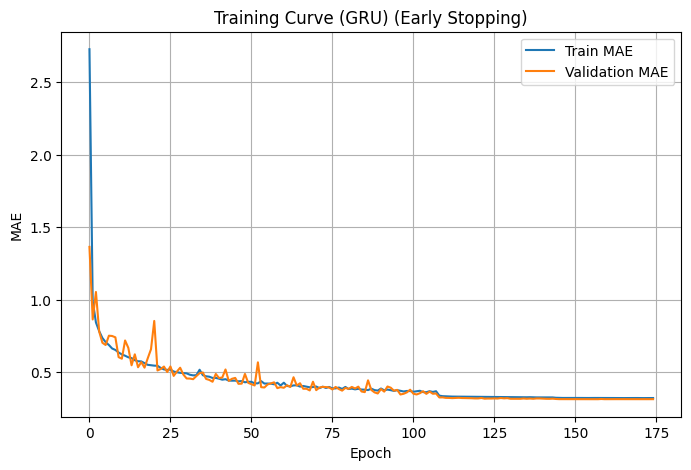

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_hist, label="Train MAE")
plt.plot(val_hist, label="Validation MAE")
plt.title("Training Curve (GRU) (Early Stopping)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True)
plt.legend()
plt.show()

Testing of Trained GRU on test data. <br>

-Collection of prediction

In [ ]:
final_model.eval()
preds = []

with torch.no_grad():
    for Xb in test_loader:
        Xb = Xb.to(device)
        preds.append(final_model(Xb).cpu().numpy())

preds = np.concatenate(preds).reshape(-1)
print("Predictions shape:", preds.shape)


Predictions shape: (4024000,)


Kaggle Submission requires the predictions to be in .csv format. <br>
With two columns **ID** and **prediction** columns

In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "pressure": preds
})

submission.to_csv("GRU_no_feature_submission.csv", index=False)
print("Saved submission.csv")
submission.head()

Saved submission.csv


,id,pressure
0,1,6.396109
1,2,6.101079
2,3,7.097018
3,4,7.752282
4,5,9.013356


In [ ]:
from google.colab import files

# Download
files.download('GRU_no_feature_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>